In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx


# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
filter_length = 2.0*snap['0_Diameters']
weight='0_Volume'
filter_type = 'gaussian'


Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [28]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [3]:
# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
                        search_radius=5.*filter_length.value)

In [35]:
def extract_turbulent_scalar(snap, sf, variable, filter_length, weight, filter_type):
    
    filt_var = sf.filter_variable(variable, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(sf.tile.particles_per_tile.min(),
                                                                    sf.tile.particles_per_tile.max(),
                                                                    cp.mean(sf.tile.particles_per_tile)))
    
    smoothVar = snap[variable].copy
    smoothVar[sf.index] = filt_var
    
    turbVar = np.zeros_like(snap[variable])
    turbVar[sf.index] = snap[variable][sf.index] - filt_var

    return smoothVar, turbVar


def extract_turbulent_energy(snap, sf, vector_variable, filter_length, weight, filter_type):
    variable_x = snap[vector_variable][:,0]
    variable_y = snap[vector_variable][:,1]
    variable_z = snap[vector_variable][:,2]
    
    filt_var_x = sf.filter_variable(variable_x, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)
    filt_var_y = sf.filter_variable(variable_y, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)
    filt_var_z = sf.filter_variable(variable_z, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(sf.tile.particles_per_tile.min(),
                                                                    sf.tile.particles_per_tile.max(),
                                                                    cp.mean(sf.tile.particles_per_tile)))
    

    smoothEner = np.zeros_like(snap[vector_variable][:,0]**2)
    smoothEner[sf.index] = 0.5*(filt_var_x**2 + filt_var_y**2 + filt_var_z**2)
    
    delta_var_x = variable_x[sf.index] - filt_var_x
    delta_var_y = variable_y[sf.index] - filt_var_y
    delta_var_z = variable_z[sf.index] - filt_var_z

    turbEner = np.zeros_like(snap[vector_variable][:,0]**2)
    turbEner[sf.index] = 0.5*(delta_var_x**2 + delta_var_y**2 + delta_var_z**2)

    return smoothEner, turbEner

In [23]:
smoothVar, turbVar = extract_turbulent_scalar(snap, sf, '0_Density', filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)

relativeTurbVar = np.zeros(snap['0_Density'].shape)
relativeTurbVar[sf.index] = turbVar[sf.index].value/snap['0_Density'][sf.index].value


99.30 percent of particles (11202707 / 11282026) has converged
min/max/avg occupancy cartesian tiling 0 / 149 / 7.12


Text(0.5, 0.95, 'Density field (iterative filter)')

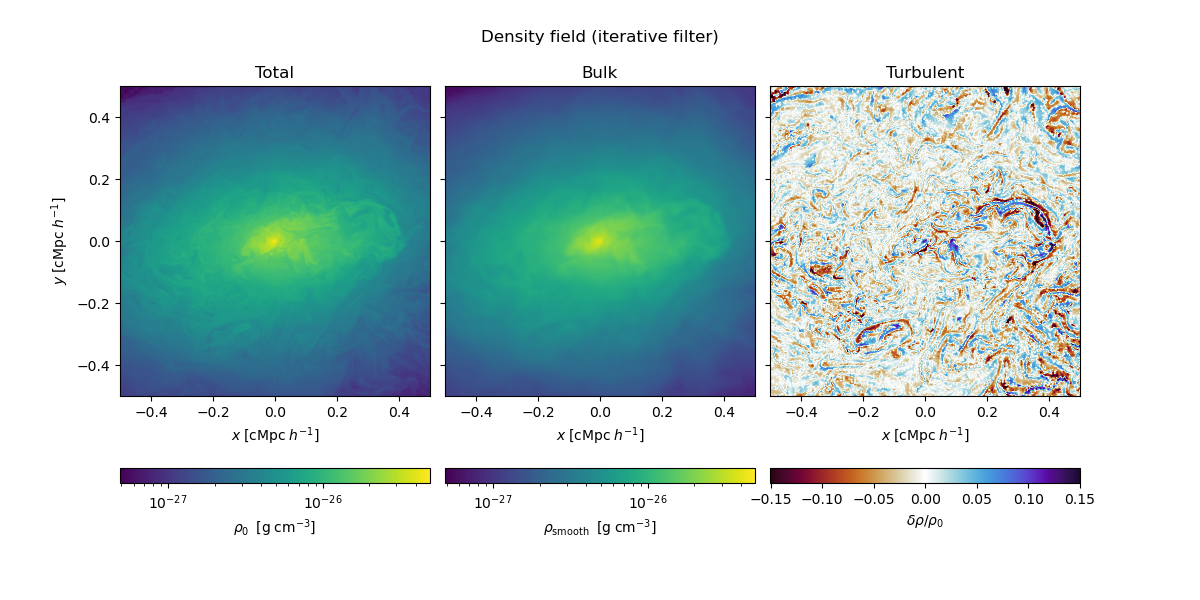

In [30]:
dens_tot = slicer.slice_variable('0_Density')
dens_bulk = slicer.slice_variable(smoothVar)
dens_turb = slicer.slice_variable(relativeTurbVar)

dens_tot = dens_tot.to_physical.cgs
dens_bulk = dens_bulk.to_physical.cgs
# dens_turb = dens_turb.to_physical.cgs

vmin = np.min(dens_tot.value)
vmax = np.max(dens_tot.value)
norm = LogNorm(vmin=vmin,vmax=vmax)


vmin = -0.8*dens_turb.max()
vmax = 0.8*dens_turb.max()
norm1 = Normalize(vmin=vmin,vmax=vmax)
cmap = cmr.fusion

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_tot.value, origin='lower', norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    dens_bulk.value, origin='lower', norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    dens_turb, origin='lower', norm=norm1,cmap=cmap,extent=extent.value)

axes[0].set_title('Total')
axes[1].set_title('Bulk')
axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_0'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_{\mathrm{smooth}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(r'$\delta \rho / \rho_0 $')



fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (iterative filter)',y=0.95)

In [36]:
smoothEner, turbEner = extract_turbulent_energy(snap, sf, '0_Velocities', filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)


97.03 percent of particles (10947207 / 11282026) has converged
97.06 percent of particles (10949898 / 11282026) has converged
97.09 percent of particles (10953336 / 11282026) has converged
min/max/avg occupancy cartesian tiling 0 / 149 / 7.12


Text(0.5, 0.95, 'Specific kinetic energy (iterative filter)')

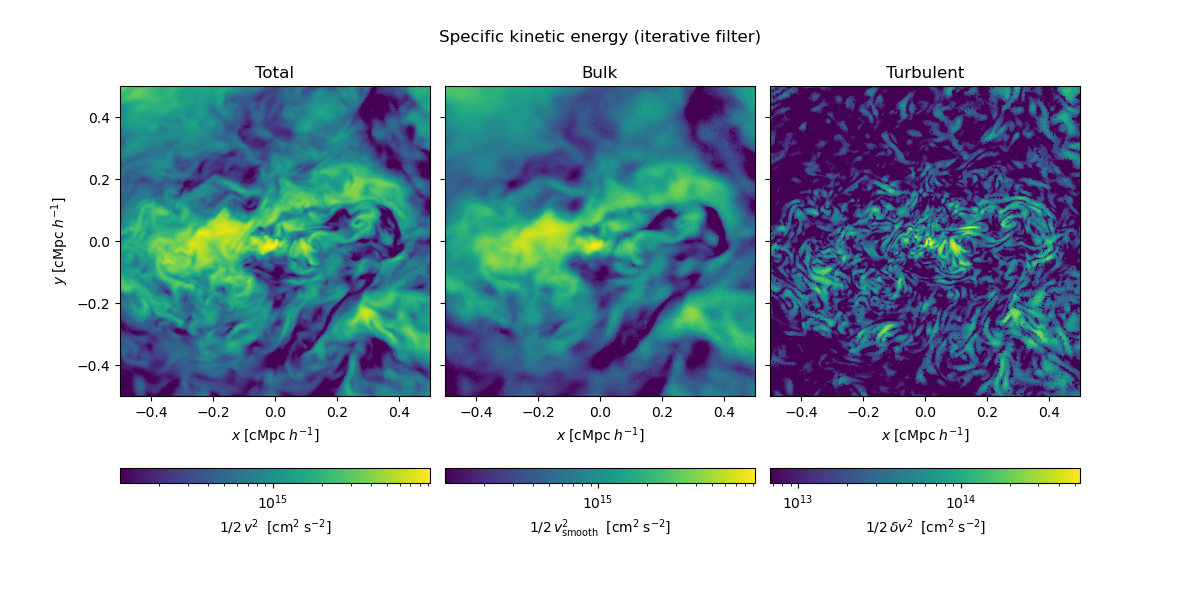

In [52]:
snap['0_KineticEnergy'] = 0.5*(snap['0_Velocities'][:,0]**2 + snap['0_Velocities'][:,1]**2 +
                               snap['0_Velocities'][:,2]**2)

kin_en_tot = slicer.slice_variable('0_KineticEnergy')
kin_en_bulk = slicer.slice_variable(smoothEner)
kin_en_turb = slicer.slice_variable(turbEner)

kin_en_tot = kin_en_tot.to_physical.cgs
kin_en_bulk = kin_en_bulk.to_physical.cgs
kin_en_turb = kin_en_turb.to_physical.cgs

vmin = 0.01*kin_en_tot.value.max()
vmax = 0.8*kin_en_tot.value.max()
norm = LogNorm(vmin=vmin,vmax=vmax)


vmin = 0.01*kin_en_turb.value.max()
vmax = 0.8*kin_en_turb.value.max()
norm1 = LogNorm(vmin=vmin,vmax=vmax)
# cmap = cmr.fusion

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    kin_en_tot.value, origin='lower', norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    kin_en_bulk.value, origin='lower', norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    kin_en_turb.value, origin='lower', norm=norm1,extent=extent.value)

axes[0].set_title('Total')
axes[1].set_title('Bulk')
axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(kin_en_tot.label('1/2 \, v^2'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(kin_en_tot.label('1/2 \, v_{\mathrm{smooth}}^2'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(kin_en_tot.label('1/2 \, \\delta v^2'))

fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Specific kinetic energy (iterative filter)',y=0.95)